## RED NEURONAL CONVOLUCIONAL

En este notebook implementaremos una **Red Neuronal Convoluciona (CNN)**. Esta arquitectura aprovecha la jerarquía espacial de las imágenes de Fashion-MNIST mediante una capa convolucional y la operación *Global Average Pooling (GAP).*

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.datasets import fashion_mnist
from keras.optimizers import Adam
#from models import build_conv_minimal

# 1. Carga de datos
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# 2. Preprocesamiento: Normalización y Reshape para CNN (28, 28, 1)
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. División de datos (Entrenamiento, Validación, Test)
X, X_val, y, y_val = train_test_split(X_train_full, y_train_full,
                                      test_size=0.2, random_state=42,
                                      stratify=y_train_full)

print(f"X (Train): {X.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X (Train): (48000, 28, 28, 1), X_val: (12000, 28, 28, 1), X_test: (10000, 28, 28, 1)


##2. Definición del Modelo CNN

Diseñaremos una arquitectura basada en Redes Neuronales Convolucionales (CNN) siguiendo el principio de mínima complejidad. La convolución utiliza filtros locales que permiten capturar patrones espaciales y texturas, elementos clave en imágenes de prendas de ropa.

La arquitectura propuesta es un ejercicio de eficiencia extrema que utiliza:

1. **Capa Convolucional:** Con kernels de $3 \times 3$ para extraer rasgos característicos (bordes, uniones, tramas).
2. **Activación ReLU:** Para introducir la no linealidad necesaria que permite distinguir formas complejas.
3. **Global Average Pooling (GAP):** En lugar de aplanar la imagen y usar capas densas (que dispararían el número de parámetros), el GAP reduce cada mapa de características a su promedio, conectando directamente con la salida.



In [ ]:
import sys
from pathlib import Path

# Añadimos el directorio raíz del proyecto al sys.path
# Como estamos en /notebooks, el raíz es el padre (parent)
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Ahora ya podemos importar desde la carpeta models
from models.CNN import build_conv_minimal

print(f"Raíz del proyecto añadida: {PROJECT_ROOT}")


Raíz del proyecto añadida: d:\Uni\Aprendizaje profundo\ProyectoAP


## 3. Entrenamiento

Entrenamos el modelo y visualizamos las curvas de aprendizaje.

In [ ]:
# Instanciamos el modelo de model.py
model = build_conv_minimal()
model.summary()

# Entrenamiento
history = model.fit(X, y,
                    epochs=50,
                    batch_size=64,
                    validation_data=(X_val, y_val),
                    verbose=1)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 16)     │         1,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,726 (6.74 KB)

 Trainable params: 1,726 (6.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5357 - loss: 1.2761 - val_accuracy: 0.6563 - val_loss: 0.9997
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6791 - loss: 0.9184 - val_accuracy: 0.7191 - val_loss: 0.8217
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7218 - loss: 0.8033 - val_accuracy: 0.7163 - val_loss: 0.8023
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7430 - loss: 0.7364 - val_accuracy: 0.7533 - val_loss: 0.7088
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7568 - loss: 0.6987 - val_accuracy: 0.7667 - val_loss: 0.6887
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7639 - loss: 0.6745 - val_accuracy: 0.7646 - val_loss: 0.6795
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7692 - loss: 0.6573 - val_accuracy: 0.7808 - val_loss: 0.6347
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7775 - loss: 0.6337 - val_accuracy: 0.

## 4. Matriz de Confusión

Visualizamos dónde se confunde el modelo utilizando el conjunto de test.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step


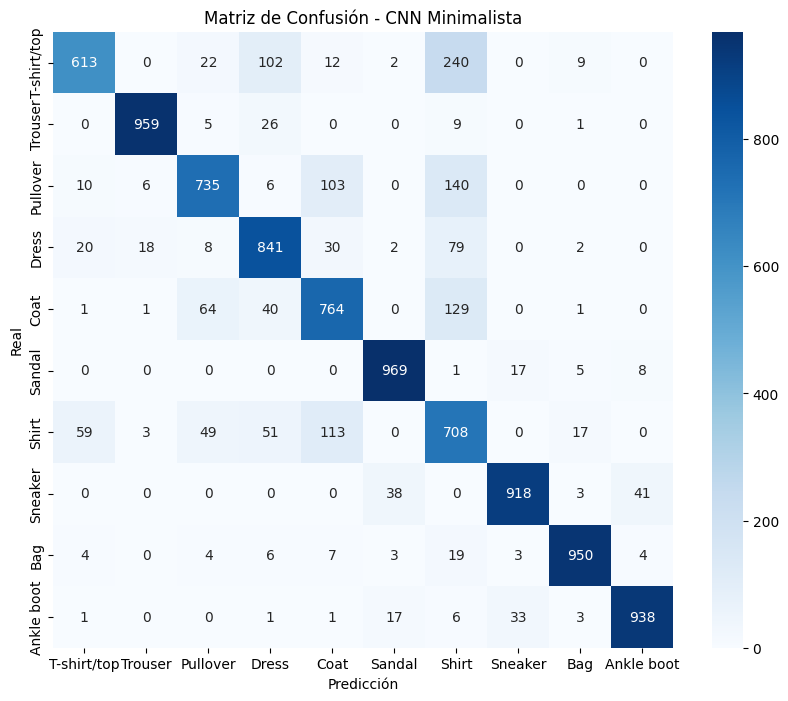

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - CNN Minimalista')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## 5. Evaluación Final

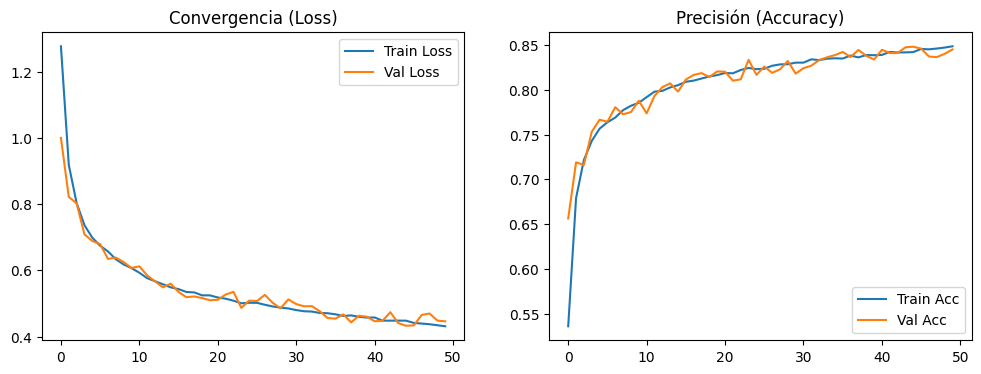

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step

--- RESULTADOS FINALES ---
Train Acc: 0.8490 | Val Acc: 0.8454 | Test Acc: 0.8395
Parámetros: 1726


In [ ]:
# Curvas de Aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Convergencia (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Precisión (Accuracy)')
plt.legend()
plt.show()

# Evaluación en Test
y_pred = np.argmax(model.predict(X_test), axis=1)
test_acc = accuracy_score(y_test, y_pred)
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n--- RESULTADOS FINALES ---")
print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")
print(f"Parámetros: {model.count_params()}")

## Resumen de Resultados - CNN

| Modelo | Parámetros |Train Acc | Val Acc | Test Acc
| :--- | :---: | :---: | :---: |:---
| **CNN** | 1,726 | 0.8490 | 0.8454 | 0.8395

### Análisis del Modelo CNN

Hemos construido una Red CNN sencilla con solo 2 capas convulucionales y global_average_pooling2d.

Al principio había bastante cuello de botella ya que la red obtenía mejores resultados en validación en la primeras épocas, después ya se estabilizaba.
Al ajustar el learning rate a 0.01 y el orden correcto del los filtros en las capas convulucionales, vemos una mejora significativa.

Se observa que el modelo no es tan preciso con clases que son muy similares.
Nuestro principal reto será conseguir que el modelo clasifique bien las clases muy similares como Camisas y Abrigos.

Podremos añadir más capas al modelo y/o probar funciones de perdida ajustadas para penalizar más los errores en las clases muy similares.
